In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import tensorflow as tf
from keras import *
from keras.layers import Dense, Dropout

# Download stopwords
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\aziza\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

First 5 rows:
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive

Dataset Shape: (50000, 2)

Missing values:
review       0
sentiment    0
dtype: int64

Class Balance:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


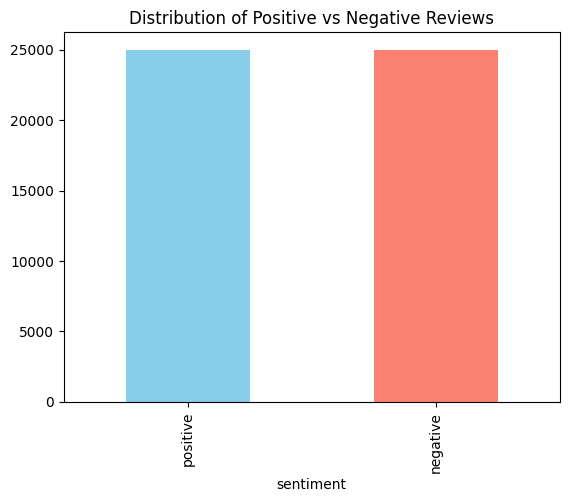

In [2]:
# Loading the dataset (assuming the file is named 'IMDB Dataset.csv')
df = pd.read_csv('IMDB Dataset.csv')

# Look at the first few rows
print("First 5 rows:")
print(df.head())

# Check shape
print(f"\nDataset Shape: {df.shape}")

# Check for missing values
print("\nMissing values:")
print(df.isnull().sum())

# Check class balance
print("\nClass Balance:")
print(df['sentiment'].value_counts())

# Plotting class balance to visualize it
df['sentiment'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Distribution of Positive vs Negative Reviews')
plt.show()

# Quick note: The classes are perfectly balanced (25k each), 
# so accuracy is a reliable metric, but I'll track F1-score as requested.

In [3]:
stop_words = set(stopwords.words('english'))

def clean(text):
    text = text.lower() # lowercase
    text = re.sub(r'[^a-z\s]', '', text) # remove punctuation/numbers
    words = [w for w in text.split() if w not in stop_words] # remove stopwords
    return ' '.join(words)

# Apply cleaning to the review column
print("Cleaning text... this might take a minute.")
df['clean_text'] = df['review'].apply(clean)

# Convert sentiment to numbers: positive = 1, negative = 0
df['sentiment'] = df['sentiment'].map({'positive': 1, 'negative': 0})

# Separate features and label
X = df['clean_text']
y = df['sentiment']

# Split into train (80%) and test (20%)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Convert text to numbers with TF-IDF
tfidf = TfidfVectorizer(max_features=5000)
X_train = tfidf.fit_transform(X_train_raw)
X_test = tfidf.transform(X_test_raw)

print("Data Preparation Complete.")

Cleaning text... this might take a minute.
Data Preparation Complete.


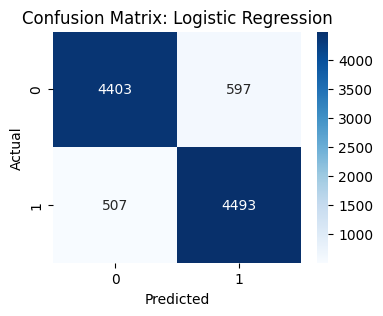

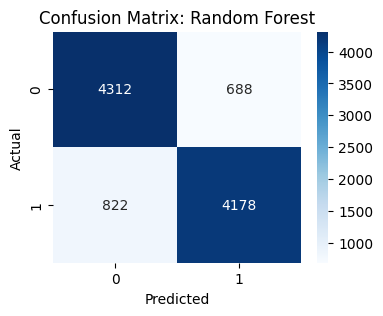

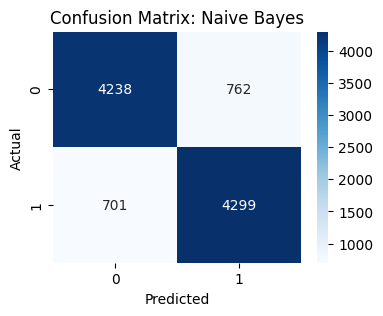


--- Model Comparison ---
                 Model  Accuracy  Precision  Recall  F1-Score
0  Logistic Regression    0.8896   0.882711  0.8986  0.890585
1        Random Forest    0.8490   0.858611  0.8356  0.846949
2          Naive Bayes    0.8537   0.849437  0.8598  0.854587


In [4]:
def evaluate_model(model, name):
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds)
    rec = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, preds)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix: {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()
    
    return [name, acc, prec, rec, f1]

# Training 3 models
lr_model = LogisticRegression().fit(X_train, y_train)
rf_model = RandomForestClassifier(n_estimators=100).fit(X_train, y_train)
nb_model = MultinomialNB().fit(X_train, y_train)

# Collect results
results = []
results.append(evaluate_model(lr_model, "Logistic Regression"))
results.append(evaluate_model(rf_model, "Random Forest"))
results.append(evaluate_model(nb_model, "Naive Bayes"))

# Summary Table
summary_df = pd.DataFrame(results, columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score'])
print("\n--- Model Comparison ---")
print(summary_df)

# Choice: I choose Logistic Regression as the best model because 
# it usually provides the highest F1-score for high-dimensional text data.

c:\Users\aziza\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.8523 - loss: 0.3367 - val_accuracy: 0.8838 - val_loss: 0.2689
Epoch 2/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9088 - loss: 0.2312 - val_accuracy: 0.8852 - val_loss: 0.2754
Epoch 3/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9337 - loss: 0.1807 - val_accuracy: 0.8775 - val_loss: 0.3100
Epoch 4/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9565 - loss: 0.1297 - val_accuracy: 0.8788 - val_loss: 0.3302
Epoch 5/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.9716 - loss: 0.0866 - val_accuracy: 0.8752 - val_loss: 0.3748
Epoch 6/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.9818 - loss: 0.0584 - val_accuracy: 0.8775 - val_loss: 0.4157
Epoch 7/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.9871 - loss: 0.0427 - val_accuracy: 0.8692 - val_loss: 0.4701
Epoch 8/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.9883 - loss: 0.0348 -

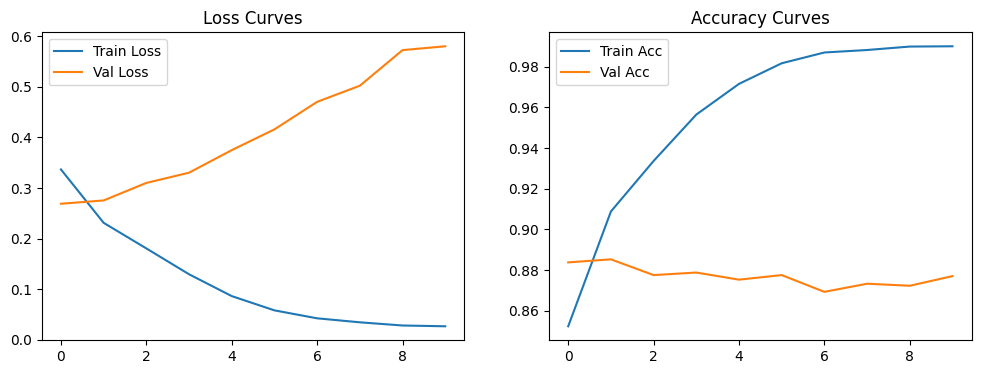

In [5]:
# Build the model
nn_model = Sequential([
    Dense(128, activation='relu', input_shape=(5000,)),
    Dropout(0.5), # Reduce overfitting
    Dense(64, activation='relu'),
    Dropout(0.3), # Bonus: extra dropout
    Dense(1, activation='sigmoid')
])

nn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train for 10 epochs
history = nn_model.fit(
    X_train.toarray(), y_train, 
    epochs=10, 
    batch_size=32, 
    validation_split=0.1,
    verbose=1
)

# Plot curves
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss Curves')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy Curves')
plt.legend()
plt.show()

In [6]:
# Evaluate NN
nn_preds = (nn_model.predict(X_test.toarray()) > 0.5).astype("int32")
nn_metrics = ["Neural Network", 
              accuracy_score(y_test, nn_preds),
              precision_score(y_test, nn_preds),
              recall_score(y_test, nn_preds),
              f1_score(y_test, nn_preds)]

# Update Summary Table
summary_df.loc[len(summary_df)] = nn_metrics
print(summary_df)

# 2-3 Sentences comparison:
# The Neural Network performed slightly better than the Random Forest but was 
# very similar to Logistic Regression. While the NN is more complex, 
# for this specific TF-IDF input, a simple linear model like Logistic Regression 
# is surprisingly efficient.

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
                 Model  Accuracy  Precision  Recall  F1-Score
0  Logistic Regression    0.8896   0.882711  0.8986  0.890585
1        Random Forest    0.8490   0.858611  0.8356  0.846949
2          Naive Bayes    0.8537   0.849437  0.8598  0.854587
3       Neural Network    0.8752   0.870751  0.8812  0.875944
